In [37]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier #Modelo
from sklearn.model_selection import train_test_split #Seccionar datos
from sklearn.compose import make_column_transformer #Para transformar las variables cualitativas
from sklearn.preprocessing import OneHotEncoder #Método de códificación de las variables cualitativas para que entienda el modelo
from sklearn.pipeline import Pipeline

#Gráficas
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.express as px

#Para métricas y evaluación
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

#**Extracción y análisis de los datos**

In [2]:
datos = pd.read_csv('/content/archivo_limpio.csv')

In [3]:
datos.head()

,aerolinea,origen,destino,distancia_km,retraso,anio,mes,es_fin_semana,bloque_horario
0,IB,MAD,EZE,7652,0,2025,1,0,madrugada
1,G3,GRU,MIA,9813,1,2025,1,0,madrugada
2,AA,GRU,EZE,2447,0,2025,1,0,madrugada
3,G3,AEP,EZE,4744,1,2025,1,0,madrugada
4,G3,MAD,MIA,8372,1,2025,1,0,madrugada


In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   aerolinea       120000 non-null  object
 1   origen          120000 non-null  object
 2   destino         120000 non-null  object
 3   distancia_km    120000 non-null  int64 
 4   retraso         120000 non-null  int64 
 5   anio            120000 non-null  int64 
 6   mes             120000 non-null  int64 
 7   es_fin_semana   120000 non-null  int64 
 8   bloque_horario  120000 non-null  object
dtypes: int64(5), object(4)
memory usage: 8.2+ MB


In [5]:
Datos_prueba = datos.drop_duplicates()

In [6]:
Datos_prueba.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119996 entries, 0 to 119999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   aerolinea       119996 non-null  object
 1   origen          119996 non-null  object
 2   destino         119996 non-null  object
 3   distancia_km    119996 non-null  int64 
 4   retraso         119996 non-null  int64 
 5   anio            119996 non-null  int64 
 6   mes             119996 non-null  int64 
 7   es_fin_semana   119996 non-null  int64 
 8   bloque_horario  119996 non-null  object
dtypes: int64(5), object(4)
memory usage: 9.2+ MB


##**Análisis de variables categóricas**

In [7]:
px.histogram(Datos_prueba, x='aerolinea', text_auto=True, color='retraso', barmode='group') #Se observa influencia en las diferentes
# Aerolineas

In [8]:
px.histogram(Datos_prueba, x='origen', text_auto=True, color='retraso', barmode='group') #Existe una semejanza en la distribución de
# retrazos entre los diferentes lugares de origen, por lo taanto es muy poco influyente en la variable dependiente

In [9]:
px.histogram(Datos_prueba, x='destino', text_auto=True, color='retraso', barmode='group') #Existe una semejanza en la distribución de
# retrazos entre los diferentes lugares de destino, por lo taanto es muy poco influyente en la variable dependiente

In [10]:
px.histogram(Datos_prueba, x='bloque_horario', text_auto=True, color='retraso', barmode='group') #Se observa influencia en los diferentes
# bloques horarios

#**Anáñisis de variables numéricas**

In [11]:
px.box(Datos_prueba, x='distancia_km', color='retraso') #Se visualiza una mínima influencia en la variable dependiente

In [12]:
px.box(datos, x='anio', color='retraso') #Se visualiza una ligera asimetría en el diagrama de caja pero tanto el retraso como
# el no retraso se ven afectados de la misma manera, es probable que se trate de cantidad

<Axes: xlabel='anio', ylabel='Count'>

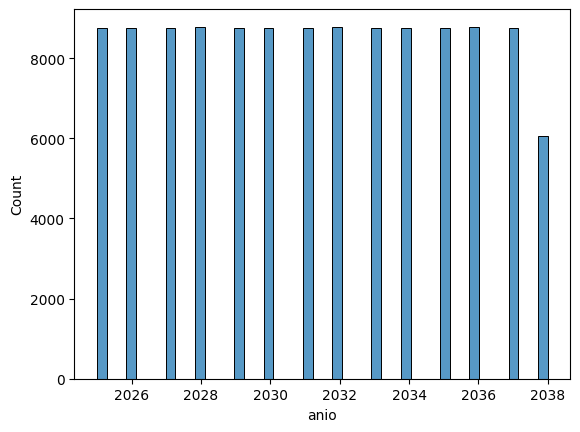

In [13]:
sns.histplot(Datos_prueba['anio']) #Se prueba que efectivamente hay una variación de cantidad en la simulación del último año
# por lo tanto es la causa de la asimetría y no se evidencia influencia en la variable dependiente

In [14]:
px.box(Datos_prueba, x='mes', color='retraso') #No se visualiza influencia en la variable dependiente

##**Separación de variables**

In [15]:
y = Datos_prueba['retraso']

In [16]:
X = Datos_prueba.drop(columns=['retraso','origen','destino','es_fin_semana','mes','anio','distancia_km']) #Se elimina la variable dependiente
#y las variables independientes no influyentes

In [17]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119996 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   aerolinea       119996 non-null  object
 1   bloque_horario  119996 non-null  object
dtypes: object(2)
memory usage: 2.7+ MB


In [18]:
one_hot = make_column_transformer((OneHotEncoder(drop='if_binary'),['aerolinea','bloque_horario']),
                                  remainder='passthrough',
                                  sparse_threshold= 0,
                                  force_int_remainder_cols=False)

In [19]:
X = one_hot.fit_transform(X)

In [20]:
one_hot.get_feature_names_out()

array(['onehotencoder__aerolinea_AA', 'onehotencoder__aerolinea_AR',
       'onehotencoder__aerolinea_G3', 'onehotencoder__aerolinea_IB',
       'onehotencoder__aerolinea_LA',
       'onehotencoder__bloque_horario_madrugada',
       'onehotencoder__bloque_horario_mañana',
       'onehotencoder__bloque_horario_noche',
       'onehotencoder__bloque_horario_tarde'], dtype=object)

In [21]:
pd.DataFrame(X, columns = one_hot.get_feature_names_out())

,onehotencoder__aerolinea_AA,onehotencoder__aerolinea_AR,onehotencoder__aerolinea_G3,onehotencoder__aerolinea_IB,onehotencoder__aerolinea_LA,onehotencoder__bloque_horario_madrugada,onehotencoder__bloque_horario_mañana,onehotencoder__bloque_horario_noche,onehotencoder__bloque_horario_tarde
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
119991,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
119992,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
119993,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
119994,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [22]:
X,X_test,y,y_test = train_test_split(X,y,test_size=0.15,stratify=y,random_state=5)
X_train,X_val,y_train,y_val = train_test_split(X,y,stratify=y,random_state=5)

In [23]:
modelo_arbol_1 = DecisionTreeClassifier(max_depth=10)

In [24]:
modelo_arbol_1.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=10)

In [25]:
modelo_arbol_1.score(X_val,y_val)

0.8434448409741558

In [26]:
modelo_arbol_1.score(X_test,y_test)

0.8432222222222222

In [27]:
def evaluar_modelo(nombre, pipeline, X_train, y_train, X_test, y_test):
    # Fit
    pipeline.fit(X_train, y_train)

    # Predicciones
    y_pred_train = pipeline.predict(X_train)
    y_pred_test  = pipeline.predict(X_test)

    # Métricas (binarias)
    metrics = {
        "Modelo": nombre,
        "Train Accuracy": accuracy_score(y_train, y_pred_train),
        "Test Accuracy": accuracy_score(y_test, y_pred_test),
        "Test Precision": precision_score(y_test, y_pred_test, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred_test, zero_division=0),
        "Test F1": f1_score(y_test, y_pred_test, zero_division=0),
    }

    # Matriz de confusión y desglose
    cm = confusion_matrix(y_test, y_pred_test)
    tn, fp, fn, tp = cm.ravel()
    metrics.update({
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    })

    return metrics, y_pred_test, cm


def mostrar_matriz_confusion(cm, titulo):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(titulo)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

In [36]:
dt_depths = [1, 2, 3, None]  # pruebas básicas

resultados = []

for depth in dt_depths:
    dt_pipeline = Pipeline(steps=[
        ("model", DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])

    nombre = f"DecisionTree max_depth={depth}"
    res, y_pred, cm = evaluar_modelo(nombre, dt_pipeline, X_train, y_train, X_test, y_test)
    resultados.append(res)

df_resultados_dt = pd.DataFrame(resultados).sort_values(by="Test F1", ascending=False)
df_resultados_dt.reset_index(drop=True, inplace=True)

print("=== Resultados Decision Tree (ordenados por Test F1) ===")
display(df_resultados_dt)

=== Resultados Decision Tree (ordenados por Test F1) ===


,Modelo,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,TN,FP,FN,TP
0,DecisionTree max_depth=2,0.847458,0.843222,0.813201,0.744636,0.777410,10250,1132,1690,4928
1,DecisionTree max_depth=3,0.847458,0.843222,0.813201,0.744636,0.777410,10250,1132,1690,4928
2,DecisionTree max_depth=None,0.847458,0.843222,0.813201,0.744636,0.777410,10250,1132,1690,4928
3,DecisionTree max_depth=1,0.793051,0.793444,0.897914,0.494409,0.637692,11010,372,3346,3272


In [34]:
y_previsto = modelo_arbol_1.predict(X_val)
matriz_confusion = confusion_matrix(y_val,y_previsto)

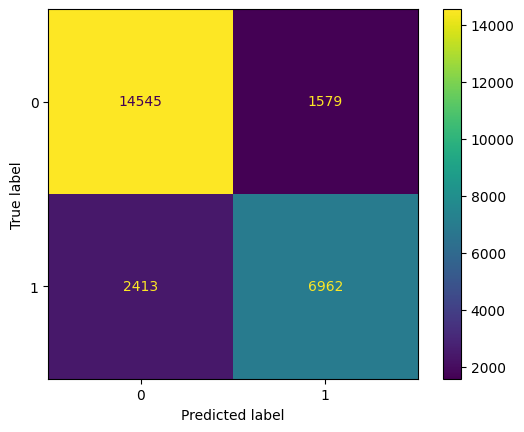

In [35]:
visual = ConfusionMatrixDisplay(matriz_confusion)
visual.plot();

#**Gradient-boosted trees**

In [39]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,      # número de árboles
    learning_rate=0.1,     # tasa de aprendizaje
    max_depth=2,           # árbol superficial (decision stump)
    subsample=1.0,         # usar todos los datos
    random_state=42
)


In [40]:
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=2, random_state=42)

In [41]:
y_pred = gb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8432222222222222
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     11382
           1       0.81      0.74      0.78      6618

    accuracy                           0.84     18000
   macro avg       0.84      0.82      0.83     18000
weighted avg       0.84      0.84      0.84     18000



In [46]:
y_previsto = gb_model.predict(X_val)
matriz_confusion2 = confusion_matrix(y_val,y_previsto)

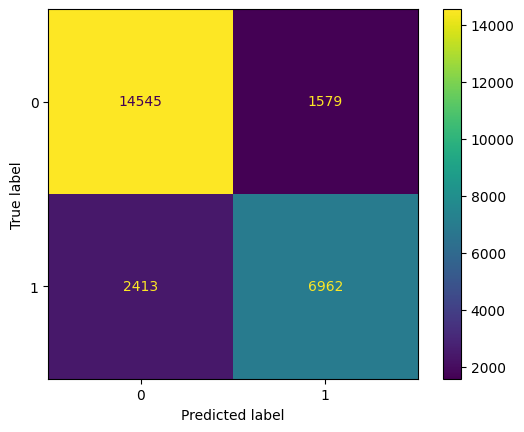

In [47]:
visual2 = ConfusionMatrixDisplay(matriz_confusion2)
visual2.plot();

#****